# MeAJOR Deep Learning Baselines

This notebook trains and evaluates two deep learning models, which are TextCNN and BiLSTM, on the processed MeAJOR dataset using the Keras/TensorFlow framework. Both models use a shared tokenisation pipeline and are evaluated using the same metrics schema as the classical baseline for direct comparison.

> **Note on framework choice:** The Kaggle deep learning notebook uses PyTorch. Keras/TensorFlow was chosen here because its high-level `fit` API is well-suited to this dataset's scale (62k training samples) and makes early-stopping and validation splits trivial to configure. Both notebooks share the same evaluation schema (Accuracy, Precision, Recall, F1, FPR, Inference Time), so cross-dataset comparison remains valid at the results level.

## 1. Import Libraries
All libraries needed for loading data, building and training deep learning models, and evaluating and saving results are imported here.

In [1]:
import time
from pathlib import Path

import numpy as np
import pandas as pd

# Keras utilities for building and training deep learning models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, GlobalMaxPooling1D,
    Bidirectional, LSTM, Dense, Dropout, Concatenate
)
from tensorflow.keras.callbacks import EarlyStopping

# Metrics for evaluating model performance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

## 2. Load Processed Data
The train and test Parquet files produced by `meajor_preparation.ipynb` are loaded here. These contain the cleaned `text` and `label` columns only.

In [2]:
# Path to the folder containing the processed MeAJOR parquet files
data_dir = Path("../data/processed/meajor/")

# Load the 60% training split
train_df = pd.read_parquet(data_dir / "meajor_train_60.parquet")

# Load the 40% test split
test_df = pd.read_parquet(data_dir / "meajor_test_40.parquet")

print(f"Train size: {len(train_df)} rows")
print(f"Test size:  {len(test_df)} rows")
print(f"Columns: {train_df.columns.tolist()}")

Train size: 62743 rows
Test size:  41829 rows
Columns: ['text', 'label']


## 3. Verify Loaded Data
A quick check to confirm the data loaded correctly, the label distribution is preserved, and sample rows look as expected before modelling begins.

In [3]:
# Preview the first 3 rows to confirm structure looks correct
print(train_df.head(3))
print()

# Confirm label balance matches the full dataset
print("Train label distribution:")
print(train_df["label"].value_counts())
print()
print("Test label distribution:")
print(test_df["label"].value_counts())

                                                text  label
0  Subject: OVER [FINANCIAL_INFO] Body: HAS ANY O...      0
1  Subject: Or each ellenton Body: THE ALERT IS O...      1
2  Subject: Best place to find cure for your dise...      1

Train label distribution:
label
0    34768
1    27975
Name: count, dtype: int64

Test label distribution:
label
0    23179
1    18650
Name: count, dtype: int64


## 4. Prepare Features and Labels
The text (features) and label (target) are separated for both splits and checked for null values before tokenisation.

In [4]:
# Separate text and labels for training
X_train = train_df["text"].astype(str)
y_train = train_df["label"].values

# Separate text and labels for testing
X_test = test_df["text"].astype(str)
y_test = test_df["label"].values

# Confirm no null values remain in either split
print(f"Null values in X_train: {train_df['text'].isna().sum()}")
print(f"Null values in X_test:  {test_df['text'].isna().sum()}")
print(f"X_train: {len(X_train)} samples")
print(f"X_test:  {len(X_test)} samples")

Null values in X_train: 0
Null values in X_test:  0
X_train: 62743 samples
X_test:  41829 samples


## 5. Tokenisation and Padding
Each email's text is converted into a sequence of integers using Keras's Tokeniser, then padded to a fixed length so every input to the model is the same size.

In [5]:
# Maximum number of unique words to keep in the vocabulary
VOCAB_SIZE = 50000

# Maximum number of tokens per email — emails longer than this are truncated
MAX_LEN = 512

# Fit the tokeniser on training text only to prevent data leakage
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

# Convert text to integer sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Pad sequences so all inputs are the same length
# post padding adds zeros at the end of shorter sequences
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding="post", truncating="post")

print(f"Training matrix shape: {X_train_pad.shape}")
print(f"Test matrix shape:     {X_test_pad.shape}")

Training matrix shape: (62743, 512)
Test matrix shape:     (41829, 512)


## 6. Build TextCNN Model
A Convolutional Neural Network is defined that applies filters of different sizes across the token sequence to detect local phishing-indicative phrases.

In [6]:
# Dimension of the dense vector representing each token
EMBEDDING_DIM = 128

def build_textcnn(vocab_size, embedding_dim, max_len):
    inputs = Input(shape=(max_len,))

    # Embedding layer converts token integers into dense vectors
    x = Embedding(vocab_size, embedding_dim)(inputs)

    # Three parallel convolution filters of different sizes to capture different phrase lengths
    # Kernel sizes 2/3/4 match the Kaggle DL notebook for cross-dataset consistency
    conv2 = Conv1D(128, kernel_size=2, activation="relu")(x)
    conv3 = Conv1D(128, kernel_size=3, activation="relu")(x)
    conv4 = Conv1D(128, kernel_size=4, activation="relu")(x)

    # GlobalMaxPooling picks the most important feature from each filter
    pool2 = GlobalMaxPooling1D()(conv2)
    pool3 = GlobalMaxPooling1D()(conv3)
    pool4 = GlobalMaxPooling1D()(conv4)

    # Concatenate the three pooled outputs into one feature vector
    concat = Concatenate()([pool2, pool3, pool4])

    # Dropout randomly disables neurons during training to prevent overfitting
    dropped = Dropout(0.5)(concat)

    # Final output layer with sigmoid activation for binary classification
    outputs = Dense(1, activation="sigmoid")(dropped)

    model = Model(inputs, outputs)
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

textcnn_model = build_textcnn(VOCAB_SIZE, EMBEDDING_DIM, MAX_LEN)
textcnn_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 512)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 512, 128)  │  6,400,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 511, 128)  │     32,896 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 510, 128)  │     49,280 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 509, 128)  │     65,664 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_1[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_2[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 384)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 384)       │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │        385 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,548,225 (24.98 MB)

 Trainable params: 6,548,225 (24.98 MB)

 Non-trainable params: 0 (0.00 B)

## 7. Train TextCNN
The TextCNN model is trained for up to 10 epochs with early stopping to prevent overfitting. A validation split is used to monitor performance during training.

In [7]:
# Early stopping halts training if validation loss stops improving for 3 consecutive epochs
early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

# Train the model using 10% of training data as a validation set
textcnn_history = textcnn_model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
883/883 ━━━━━━━━━━━━━━━━━━━━ 72s 80ms/step - accuracy: 0.8918 - loss: 0.2429 - val_accuracy: 0.9820 - val_loss: 0.0554
Epoch 2/10
883/883 ━━━━━━━━━━━━━━━━━━━━ 71s 81ms/step - accuracy: 0.9883 - loss: 0.0351 - val_accuracy: 0.9834 - val_loss: 0.0506
Epoch 3/10
883/883 ━━━━━━━━━━━━━━━━━━━━ 150s 169ms/step - accuracy: 0.9961 - loss: 0.0145 - val_accuracy: 0.9804 - val_loss: 0.0613
Epoch 4/10
883/883 ━━━━━━━━━━━━━━━━━━━━ 570s 646ms/step - accuracy: 0.9982 - loss: 0.0068 - val_accuracy: 0.9823 - val_loss: 0.0612
Epoch 5/10
883/883 ━━━━━━━━━━━━━━━━━━━━ 397s 450ms/step - accuracy: 0.9987 - loss: 0.0043 - val_accuracy: 0.9841 - val_loss: 0.0689


## 8. Evaluate TextCNN
The trained TextCNN is evaluated on the held-out test set. The classification report, confusion matrix figure, and metrics are saved.

TextCNN Classification Report:
                precision    recall  f1-score   support

Legitimate (0)       0.99      0.98      0.98     23179
  Phishing (1)       0.98      0.99      0.98     18650

      accuracy                           0.98     41829
     macro avg       0.98      0.98      0.98     41829
  weighted avg       0.98      0.98      0.98     41829

  False Positive Rate (FPR): 0.0189
  Inference time (ms/email): 0.9525


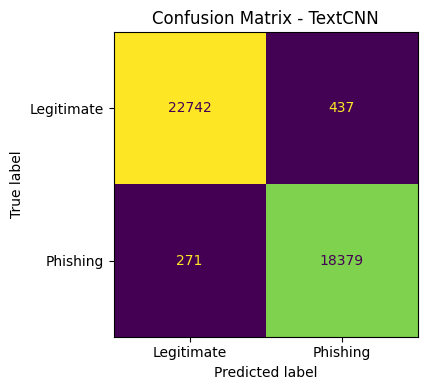

In [8]:
# Create the figures folder if it does not already exist
figures_dir = Path("../results/figures/")
figures_dir.mkdir(parents=True, exist_ok=True)

# ── Inference time: n_runs forward passes to get a stable average ──
N_RUNS = 3
_inf_times = []
for _ in range(N_RUNS):
    _t0 = time.perf_counter()
    _ = textcnn_model.predict(X_test_pad, verbose=0)
    _inf_times.append((time.perf_counter() - _t0) * 1000)
textcnn_inference_ms = round(np.mean(_inf_times) / len(X_test_pad), 4)

# ── Predictions and confusion matrix ──
textcnn_probs = textcnn_model.predict(X_test_pad, verbose=0)
textcnn_pred  = (textcnn_probs >= 0.5).astype(int).flatten()

cm_cnn = confusion_matrix(y_test, textcnn_pred)
tn, fp, fn, tp = cm_cnn.ravel()
textcnn_fpr = round(fp / (fp + tn), 4) if (fp + tn) > 0 else 0.0

# ── Classification report and extra metrics ──
print("TextCNN Classification Report:")
print(classification_report(y_test, textcnn_pred, target_names=["Legitimate (0)", "Phishing (1)"]))
print(f"  False Positive Rate (FPR): {textcnn_fpr:.4f}")
print(f"  Inference time (ms/email): {textcnn_inference_ms}")

# ── Store results for CSV export ──
results_textcnn = {
    "Model":        "TextCNN",
    "Dataset":      "MeAJOR",
    "Accuracy":     round(accuracy_score(y_test, textcnn_pred),                    4),
    "Precision":    round(precision_score(y_test, textcnn_pred, zero_division=0),  4),
    "Recall":       round(recall_score(y_test, textcnn_pred, zero_division=0),     4),
    "F1":           round(f1_score(y_test, textcnn_pred, zero_division=0),         4),
    "FPR":          textcnn_fpr,
    "Inference_ms": textcnn_inference_ms,
}

# ── Confusion matrix figure ──
disp = ConfusionMatrixDisplay(confusion_matrix=cm_cnn, display_labels=["Legitimate", "Phishing"])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False)
ax.set_title("Confusion Matrix - TextCNN")
plt.tight_layout()
plt.savefig(figures_dir / "meajor_cm_textcnn.png", dpi=150)
plt.show()

## 9. Build BiLSTM Model

A Bidirectional LSTM is defined that reads each email sequence both forwards and backwards, capturing long-range contextual patterns that CNN filters may miss.

> **Architecture note:** The MeAJOR BiLSTM includes an intermediate `Dense(64, relu)` hidden layer before the output sigmoid, whereas the Kaggle BiLSTM does not. This is an intentional design choice: the MeAJOR training set is ~45x larger (62k vs 1.4k), which supports a slightly deeper architecture and benefits from the extra representational capacity. Both models use a single Bidirectional LSTM layer with 128 hidden units, so the core sequence-processing component is identical.

In [9]:
def build_bilstm(vocab_size, embedding_dim, max_len):
    inputs = Input(shape=(max_len,))

    # Embedding layer converts token integers into dense vectors
    x = Embedding(vocab_size, embedding_dim)(inputs)

    # Dropout applied to embeddings before the LSTM to reduce overfitting
    x = Dropout(0.3)(x)

    # Bidirectional LSTM reads the sequence in both directions and concatenates the outputs
    x = Bidirectional(LSTM(128, return_sequences=False))(x)

    # Dropout applied after the LSTM layer
    x = Dropout(0.5)(x)

    # Dense hidden layer to learn higher level features
    x = Dense(64, activation="relu")(x)

    # Final output layer with sigmoid activation for binary classification
    outputs = Dense(1, activation="sigmoid")(x)

    model = Model(inputs, outputs)
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

bilstm_model = build_bilstm(VOCAB_SIZE, EMBEDDING_DIM, MAX_LEN)
bilstm_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 512, 128)       │     6,400,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,679,681 (25.48 MB)

 Trainable params: 6,679,681 (25.48 MB)

 Non-trainable params: 0 (0.00 B)

## 10. Train BiLSTM
The BiLSTM model is trained for up to 10 epochs with early stopping, using the same training configuration as TextCNN for fair comparison.

In [10]:
# Reuse the same early stopping configuration as TextCNN for fair comparison
early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

# Train the BiLSTM model with identical settings to TextCNN
bilstm_history = bilstm_model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
883/883 ━━━━━━━━━━━━━━━━━━━━ 2728s 3s/step - accuracy: 0.9103 - loss: 0.1977 - val_accuracy: 0.9704 - val_loss: 0.0952
Epoch 2/10
883/883 ━━━━━━━━━━━━━━━━━━━━ 710s 800ms/step - accuracy: 0.9836 - loss: 0.0465 - val_accuracy: 0.9783 - val_loss: 0.0669
Epoch 3/10
883/883 ━━━━━━━━━━━━━━━━━━━━ 657s 745ms/step - accuracy: 0.9927 - loss: 0.0225 - val_accuracy: 0.9756 - val_loss: 0.0915
Epoch 4/10
883/883 ━━━━━━━━━━━━━━━━━━━━ 671s 760ms/step - accuracy: 0.9928 - loss: 0.0222 - val_accuracy: 0.9747 - val_loss: 0.0749
Epoch 5/10
883/883 ━━━━━━━━━━━━━━━━━━━━ 664s 752ms/step - accuracy: 0.9954 - loss: 0.0135 - val_accuracy: 0.9433 - val_loss: 0.1559


## 11. Evaluate BiLSTM
The trained BiLSTM is evaluated on the held-out test set. The classification report, confusion matrix figure, and metrics are saved.

BiLSTM Classification Report:
                precision    recall  f1-score   support

Legitimate (0)       0.98      0.98      0.98     23179
  Phishing (1)       0.98      0.98      0.98     18650

      accuracy                           0.98     41829
     macro avg       0.98      0.98      0.98     41829
  weighted avg       0.98      0.98      0.98     41829

  False Positive Rate (FPR): 0.0177
  Inference time (ms/email): 3.1772


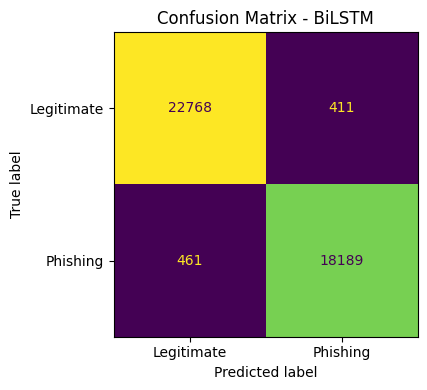

In [11]:
# ── Inference time: n_runs forward passes to get a stable average ──
_inf_times = []
for _ in range(N_RUNS):
    _t0 = time.perf_counter()
    _ = bilstm_model.predict(X_test_pad, verbose=0)
    _inf_times.append((time.perf_counter() - _t0) * 1000)
bilstm_inference_ms = round(np.mean(_inf_times) / len(X_test_pad), 4)

# ── Predictions and confusion matrix ──
bilstm_probs = bilstm_model.predict(X_test_pad, verbose=0)
bilstm_pred  = (bilstm_probs >= 0.5).astype(int).flatten()

cm_lstm = confusion_matrix(y_test, bilstm_pred)
tn, fp, fn, tp = cm_lstm.ravel()
bilstm_fpr = round(fp / (fp + tn), 4) if (fp + tn) > 0 else 0.0

# ── Classification report and extra metrics ──
print("BiLSTM Classification Report:")
print(classification_report(y_test, bilstm_pred, target_names=["Legitimate (0)", "Phishing (1)"]))
print(f"  False Positive Rate (FPR): {bilstm_fpr:.4f}")
print(f"  Inference time (ms/email): {bilstm_inference_ms}")

# ── Store results for CSV export ──
results_bilstm = {
    "Model":        "BiLSTM",
    "Dataset":      "MeAJOR",
    "Accuracy":     round(accuracy_score(y_test, bilstm_pred),                    4),
    "Precision":    round(precision_score(y_test, bilstm_pred, zero_division=0),  4),
    "Recall":       round(recall_score(y_test, bilstm_pred, zero_division=0),     4),
    "F1":           round(f1_score(y_test, bilstm_pred, zero_division=0),         4),
    "FPR":          bilstm_fpr,
    "Inference_ms": bilstm_inference_ms,
}

# ── Confusion matrix figure ──
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lstm, display_labels=["Legitimate", "Phishing"])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False)
ax.set_title("Confusion Matrix - BiLSTM")
plt.tight_layout()
plt.savefig(figures_dir / "meajor_cm_bilstm.png", dpi=150)
plt.show()

## 12. Training Curves
The training and validation loss and accuracy over epochs are plotted for both models to visualise learning behaviour and check for overfitting.

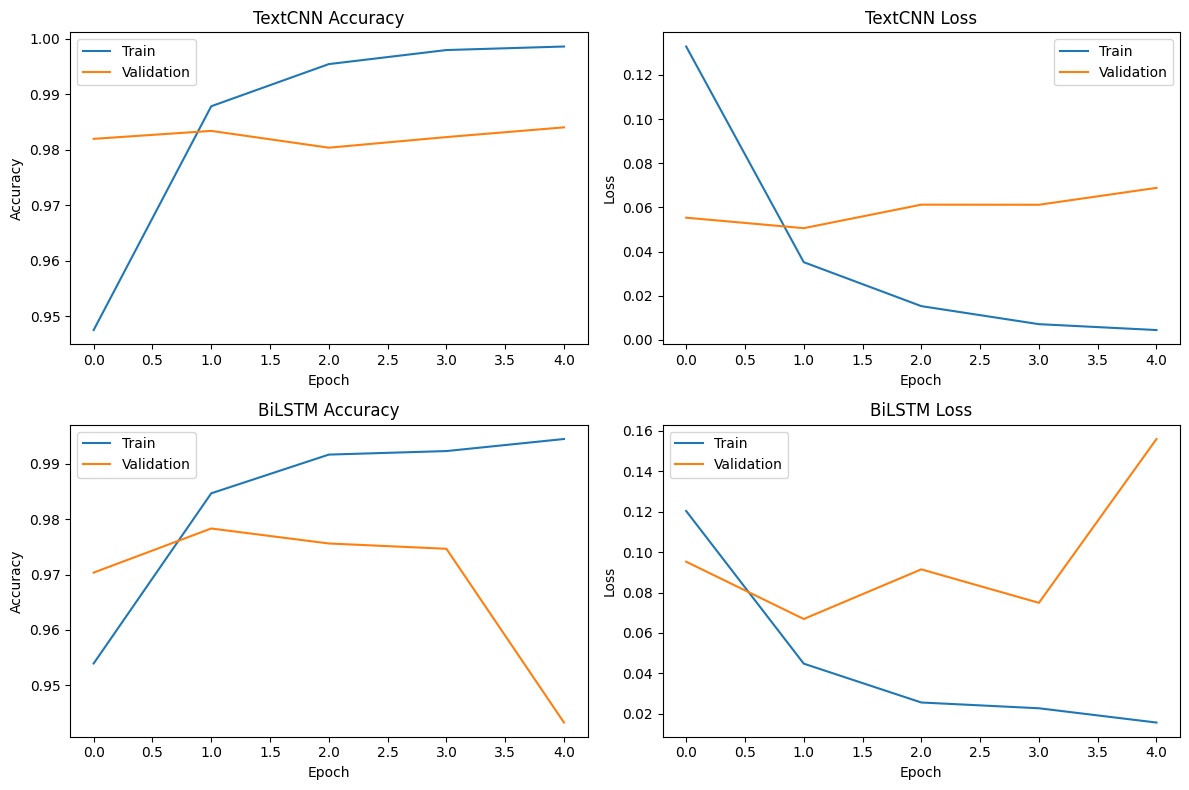

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# TextCNN training and validation accuracy over epochs
axes[0, 0].plot(textcnn_history.history["accuracy"], label="Train")
axes[0, 0].plot(textcnn_history.history["val_accuracy"], label="Validation")
axes[0, 0].set_title("TextCNN Accuracy")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Accuracy")
axes[0, 0].legend()

# TextCNN training and validation loss over epochs
axes[0, 1].plot(textcnn_history.history["loss"], label="Train")
axes[0, 1].plot(textcnn_history.history["val_loss"], label="Validation")
axes[0, 1].set_title("TextCNN Loss")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].legend()

# BiLSTM training and validation accuracy over epochs
axes[1, 0].plot(bilstm_history.history["accuracy"], label="Train")
axes[1, 0].plot(bilstm_history.history["val_accuracy"], label="Validation")
axes[1, 0].set_title("BiLSTM Accuracy")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Accuracy")
axes[1, 0].legend()

# BiLSTM training and validation loss over epochs
axes[1, 1].plot(bilstm_history.history["loss"], label="Train")
axes[1, 1].plot(bilstm_history.history["val_loss"], label="Validation")
axes[1, 1].set_title("BiLSTM Loss")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Loss")
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(figures_dir / "meajor_dl_training_curves.png", dpi=150)
plt.show()

## 13. Save Results

Final metrics for both models are saved to a CSV file in the results folder, consistent with the output format of `kaggle_dl_results.csv`.

In [13]:
results_dir = Path("../results/metrics/")
results_dir.mkdir(parents=True, exist_ok=True)

results_df = pd.DataFrame([results_textcnn, results_bilstm])
csv_path   = results_dir / "meajor_dl_baseline_results.csv"
results_df.to_csv(csv_path, index=False)

print(f"Results saved to {csv_path}")
results_df

Results saved to ../results/metrics/meajor_dl_baseline_results.csv


,Model,Dataset,Accuracy,Precision,Recall,F1,FPR,Inference_ms
0,TextCNN,MeAJOR,0.9831,0.9768,0.9855,0.9811,0.0189,0.9525
1,BiLSTM,MeAJOR,0.9792,0.9779,0.9753,0.9766,0.0177,3.1772


## 13. Results Summary
The evaluation metrics for both models are compiled into a single CSV file matching the classical baseline schema for direct comparison.

In [14]:
metrics_dir = Path("../results/metrics/")
metrics_dir.mkdir(parents=True, exist_ok=True)

summary_rows = []

for name, model, y_pred, probs in [
    ("TextCNN", textcnn_model, textcnn_pred, textcnn_probs),
    ("BiLSTM",  bilstm_model,  bilstm_pred,  bilstm_probs),
]:
    # Time inference on the test set
    start = time.time()
    model.predict(X_test_pad, verbose=0)
    elapsed = time.time() - start

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    # False positive rate is legitimate emails wrongly predicted as phishing
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    summary_rows.append({
        "dataset": "MeAJOR",
        "model": name,
        "accuracy": round(accuracy_score(y_test, y_pred), 6),
        "precision": round(precision_score(y_test, y_pred, pos_label=1), 6),
        "recall": round(recall_score(y_test, y_pred, pos_label=1), 6),
        "f1": round(f1_score(y_test, y_pred, pos_label=1), 6),
        "false_positive_rate": round(fpr, 6),
        "inference_time_total_sec": round(elapsed, 6),
        "inference_time_per_email_sec": round(elapsed / len(y_test), 9),
        "train_rows": len(y_train),
        "test_rows": len(y_test),
        "vocab_size": VOCAB_SIZE,
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string())

summary_df.to_csv(metrics_dir / "meajor_dl_baseline_results.csv", index=False)
print("\nResults saved to ../results/metrics/meajor_dl_baseline_results.csv")

  dataset    model  accuracy  precision    recall        f1  false_positive_rate  inference_time_total_sec  inference_time_per_email_sec  train_rows  test_rows  vocab_size
0  MeAJOR  TextCNN  0.983074   0.976775  0.985469  0.981103             0.018853                 13.429708                      0.000321       62743      41829       50000
1  MeAJOR   BiLSTM  0.979153   0.977903  0.975282  0.976591             0.017732                131.119996                      0.003135       62743      41829       50000

Results saved to ../results/metrics/meajor_dl_baseline_results.csv
